<a href="https://colab.research.google.com/github/prajwalbhandari416/Time-Dependent-Wave-Equations/blob/main/Feynman_Propagator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Feynman-propagator surface
Auther: Prajwal Bhandari



The central equation is

```math
D_F(p)=\frac{1}{p^2-m^2+i\epsilon}.
```

For \(m=1\), the propagator has poles near

```math
p=\pm m=\pm1.
```

The animation shows how the small \(i\epsilon\) prescription regularizes these poles.

The **cyan curve** represents the real component,

```math
\operatorname{Re}[D_F(p)],
```

while the **pink/red curve** represents the imaginary component,

```math
\operatorname{Im}[D_F(p)].
```

The bottom-left panel maps the propagator into the **complex plane**, while the bottom-right panel provides a colorful visualization of \(|D_F|\) as a function of momentum and \(\epsilon\).

If you want an even more visually impressive QFT animation, the next version can simulate **\(D_F(x,t)\) in spacetime**, featuring a propagating quantum excitation, light-cone structure, wave packets, particle–antiparticle propagation, and a **3D rotating Feynman-propagator surface**.


In [1]:
!pip install numpy matplotlib pillow

In [2]:
!apt-get update -qq
!apt-get install -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 25 not upgraded.


Rendering Feynman propagator animation...

Video successfully saved as:
feynman_propagator_colorful.mp4


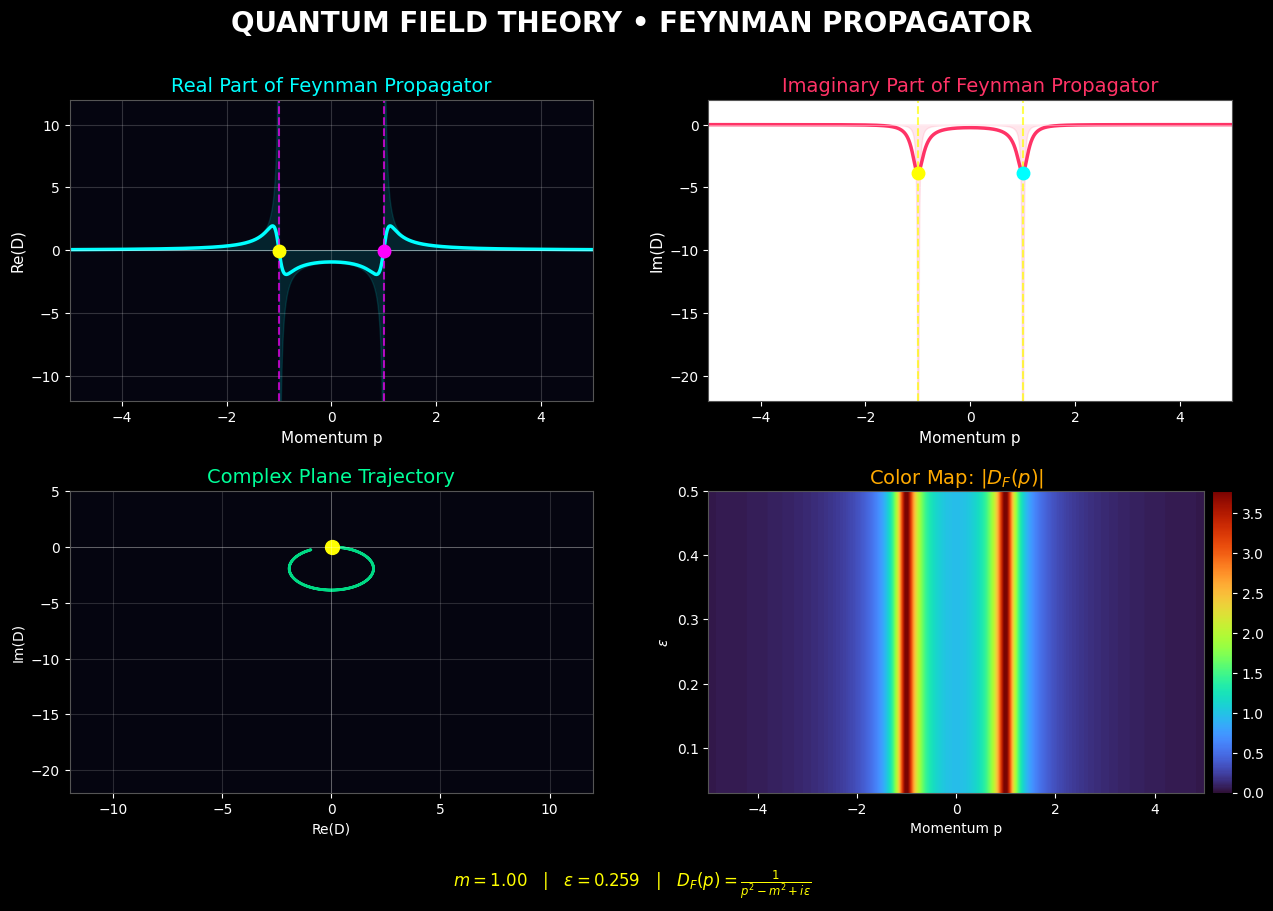

In [3]:
# ==============================================================
# COLORFUL ANIMATED FEYNMAN PROPAGATOR
# Scalar propagator:
#
#       D_F(p) = 1 / (p^2 - m^2 + i epsilon)
#
# Creates:
#   1. Re[D_F(p)] animation
#   2. Im[D_F(p)] animation
#   3. |D_F(p)| color visualization
#   4. Complex-plane trajectory
#   5. Moving particle markers
#   6. MP4 / GIF animation
#
# =============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --------------------------------------------------------------
# 1. PHYSICAL PARAMETERS
# --------------------------------------------------------------

m = 1.0                    # Mass
epsilon_min = 0.03        # Minimum regularization
epsilon_max = 0.50        # Maximum regularization

# Momentum range
p = np.linspace(-5, 5, 3000)

# Number of animation frames
N_FRAMES = 240

# --------------------------------------------------------------
# 2. FEYNMAN PROPAGATOR
# --------------------------------------------------------------

def feynman_propagator(p, m, epsilon):
    """
    Scalar Feynman propagator in momentum space:

        D_F(p) = 1 / (p^2 - m^2 + i epsilon)
    """

    denominator = p**2 - m**2 + 1j * epsilon

    return 1.0 / denominator


# --------------------------------------------------------------
# 3. INITIAL DATA
# --------------------------------------------------------------

D0 = feynman_propagator(
    p,
    m,
    epsilon_min
)

real0 = np.real(D0)
imag0 = np.imag(D0)
abs0 = np.abs(D0)


# --------------------------------------------------------------
# 4. FIGURE
# --------------------------------------------------------------

plt.close("all")

fig = plt.figure(
    figsize=(15, 9),
    facecolor="black"
)

gs = fig.add_gridspec(
    2,
    2,
    hspace=0.30,
    wspace=0.22
)

# --------------------------------------------------------------
# TOP LEFT: REAL PART
# --------------------------------------------------------------

ax1 = fig.add_subplot(gs[0, 0])

ax1.set_facecolor("#050510")

line_real, = ax1.plot(
    p,
    real0,
    lw=2.5,
    color="#00ffff",
    label="Re[D]"
)

ax1.fill_between(
    p,
    real0,
    0,
    color="#00ffff",
    alpha=0.12
)

ax1.axhline(
    0,
    color="white",
    lw=0.7,
    alpha=0.4
)

ax1.axvline(
    -m,
    color="#ff00ff",
    linestyle="--",
    alpha=0.7
)

ax1.axvline(
    m,
    color="#ff00ff",
    linestyle="--",
    alpha=0.7
)

ax1.set_xlim(-5, 5)
ax1.set_ylim(-12, 12)

ax1.set_xlabel(
    "Momentum p",
    color="white",
    fontsize=11
)

ax1.set_ylabel(
    "Re(D)",
    color="white",
    fontsize=11
)

ax1.set_title(
    "Real Part of Feynman Propagator",
    color="#00ffff",
    fontsize=14
)

ax1.tick_params(colors="white")

for spine in ax1.spines.values():
    spine.set_color("#555555")

ax1.grid(
    alpha=0.18,
    color="white"
)


# --------------------------------------------------------------
# TOP RIGHT: IMAGINARY PART
# --------------------------------------------------------------

ax2 = fig.add_subplot(gs[0, 1])

line_imag, = ax2.plot(
    p,
    imag0,
    lw=2.5,
    color="#ff3366",
    label="Im[D]"
)

ax2.fill_between(
    p,
    imag0,
    0,
    color="#ff3366",
    alpha=0.12
)

ax2.axhline(
    0,
    color="white",
    lw=0.7,
    alpha=0.4
)

ax2.axvline(
    -m,
    color="#ffff00",
    linestyle="--",
    alpha=0.7
)

ax2.axvline(
    m,
    color="#ffff00",
    linestyle="--",
    alpha=0.7
)

ax2.set_xlim(-5, 5)
ax2.set_ylim(-22, 2)

ax2.set_xlabel(
    "Momentum p",
    color="white",
    fontsize=11
)

ax2.set_ylabel(
    "Im(D)",
    color="white",
    fontsize=11
)

ax2.set_title(
    "Imaginary Part of Feynman Propagator",
    color="#ff3366",
    fontsize=14
)

ax2.tick_params(colors="white")

for spine in ax2.spines.values():
    spine.set_color("#555555")

ax2.grid(
    alpha=0.18,
    color="white"
)


# --------------------------------------------------------------
# BOTTOM LEFT: COMPLEX PLANE
# --------------------------------------------------------------

ax3 = fig.add_subplot(gs[1, 0])

ax3.set_facecolor("#050510")

complex_line, = ax3.plot(
    real0,
    imag0,
    color="#00ff99",
    lw=2,
    alpha=0.85
)

complex_point, = ax3.plot(
    [real0[len(real0)//2]],
    [imag0[len(imag0)//2]],
    "o",
    markersize=10,
    color="#ffff00"
)

ax3.axhline(
    0,
    color="white",
    lw=0.6,
    alpha=0.3
)

ax3.axvline(
    0,
    color="white",
    lw=0.6,
    alpha=0.3
)

ax3.set_xlim(-12, 12)
ax3.set_ylim(-22, 5)

ax3.set_xlabel(
    "Re(D)",
    color="white"
)

ax3.set_ylabel(
    "Im(D)",
    color="white"
)

ax3.set_title(
    "Complex Plane Trajectory",
    color="#00ff99",
    fontsize=14
)

ax3.tick_params(colors="white")

for spine in ax3.spines.values():
    spine.set_color("#555555")

ax3.grid(
    alpha=0.15,
    color="white"
)


# --------------------------------------------------------------
# BOTTOM RIGHT: PROPAGATOR MAGNITUDE
# --------------------------------------------------------------

ax4 = fig.add_subplot(gs[1, 1])

# Momentum-energy style 2D visualization
p2 = np.linspace(-5, 5, 500)

epsilon_grid = np.linspace(
    epsilon_min,
    epsilon_max,
    300
)

P, E = np.meshgrid(
    p2,
    epsilon_grid
)

D_grid = 1.0 / (
    P**2 - m**2 + 1j * E
)

magnitude = np.abs(D_grid)

image = ax4.imshow(
    magnitude,
    extent=[
        -5,
        5,
        epsilon_min,
        epsilon_max
    ],
    origin="lower",
    aspect="auto",
    cmap="turbo"
)

ax4.set_xlabel(
    "Momentum p",
    color="white"
)

ax4.set_ylabel(
    r"$\epsilon$",
    color="white"
)

ax4.set_title(
    r"Color Map: $|D_F(p)|$",
    color="#ffaa00",
    fontsize=14
)

ax4.tick_params(colors="white")

for spine in ax4.spines.values():
    spine.set_color("#555555")

# Colorbar
divider = make_axes_locatable(ax4)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

cbar = fig.colorbar(
    image,
    cax=cax
)

cbar.ax.tick_params(
    colors="white"
)

# --------------------------------------------------------------
# TITLE
# --------------------------------------------------------------

fig.suptitle(
    "QUANTUM FIELD THEORY • FEYNMAN PROPAGATOR",
    color="white",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# --------------------------------------------------------------
# INFORMATION TEXT
# --------------------------------------------------------------

info_text = fig.text(
    0.5,
    0.005,
    "",
    ha="center",
    color="#ffff00",
    fontsize=12
)


# --------------------------------------------------------------
# MOVING PARTICLE MARKERS
# --------------------------------------------------------------

particle_real, = ax1.plot(
    [-m],
    [0],
    "o",
    color="#ffff00",
    markersize=9
)

particle_real2, = ax1.plot(
    [m],
    [0],
    "o",
    color="#ff00ff",
    markersize=9
)

particle_imag, = ax2.plot(
    [-m],
    [0],
    "o",
    color="#ffff00",
    markersize=9
)

particle_imag2, = ax2.plot(
    [m],
    [0],
    "o",
    color="#00ffff",
    markersize=9
)


# --------------------------------------------------------------
# 5. ANIMATION FUNCTION
# --------------------------------------------------------------

def update(frame):

    # ----------------------------------------------------------
    # Oscillating epsilon
    # ----------------------------------------------------------

    phase = 2 * np.pi * frame / N_FRAMES

    epsilon = (
        epsilon_min
        +
        (epsilon_max - epsilon_min)
        *
        (0.5 + 0.5 * np.sin(phase))
    )

    # ----------------------------------------------------------
    # Propagator
    # ----------------------------------------------------------

    D = feynman_propagator(
        p,
        m,
        epsilon
    )

    real_part = np.real(D)
    imag_part = np.imag(D)

    # ----------------------------------------------------------
    # Update real curve
    # ----------------------------------------------------------

    line_real.set_ydata(
        real_part
    )

    # ----------------------------------------------------------
    # Update imaginary curve
    # ----------------------------------------------------------

    line_imag.set_ydata(
        imag_part
    )

    # ----------------------------------------------------------
    # Update complex trajectory
    # ----------------------------------------------------------

    complex_line.set_data(
        real_part,
        imag_part
    )

    # Moving point through momentum space
    particle_index = int(
        (frame / N_FRAMES)
        * (len(p) - 1)
    )

    particle_index = min(
        particle_index,
        len(p) - 1
    )

    complex_point.set_data(
        [real_part[particle_index]],
        [imag_part[particle_index]]
    )

    # ----------------------------------------------------------
    # Move pole markers
    # ----------------------------------------------------------

    pole_left_index = np.argmin(
        np.abs(p + m)
    )

    pole_right_index = np.argmin(
        np.abs(p - m)
    )

    particle_real.set_data(
        [-m],
        [real_part[pole_left_index]]
    )

    particle_real2.set_data(
        [m],
        [real_part[pole_right_index]]
    )

    particle_imag.set_data(
        [-m],
        [imag_part[pole_left_index]]
    )

    particle_imag2.set_data(
        [m],
        [imag_part[pole_right_index]]
    )

    # ----------------------------------------------------------
    # Animate color map
    # ----------------------------------------------------------

    magnitude_frame = np.abs(
        1.0 / (
            P**2 - m**2 + 1j * epsilon
        )
    )

    image.set_data(
        magnitude_frame
    )

    image.set_clim(
        0,
        np.percentile(
            magnitude_frame,
            99
        )
    )

    # ----------------------------------------------------------
    # Information text
    # ----------------------------------------------------------

    info_text.set_text(
        rf"$m={m:.2f}$   |   "
        rf"$\epsilon={epsilon:.3f}$   |   "
        rf"$D_F(p)=\frac{{1}}{{p^2-m^2+i\epsilon}}$"
    )

    return (
        line_real,
        line_imag,
        complex_line,
        complex_point,
        image,
        particle_real,
        particle_real2,
        particle_imag,
        particle_imag2,
        info_text
    )


# --------------------------------------------------------------
# 6. CREATE ANIMATION
# --------------------------------------------------------------

ani = FuncAnimation(
    fig,
    update,
    frames=N_FRAMES,
    interval=40,
    blit=False
)


# --------------------------------------------------------------
# 7. SAVE VIDEO
# --------------------------------------------------------------

print("Rendering Feynman propagator animation...")

try:

    writer = FFMpegWriter(
        fps=25,
        bitrate=4000,
        metadata={
            "title": "Feynman Propagator Visualization",
            "artist": "Python",
            "comment": "Quantum Field Theory simulation"
        }
    )

    ani.save(
        "feynman_propagator_colorful.mp4",
        writer=writer,
        dpi=120
    )

    print(
        "\nVideo successfully saved as:"
    )

    print(
        "feynman_propagator_colorful.mp4"
    )

except Exception as e:

    print(
        "\nFFmpeg was not available."
    )

    print(
        "Creating GIF instead..."
    )

    ani.save(
        "feynman_propagator_colorful.gif",
        writer=PillowWriter(
            fps=20
        ),
        dpi=100
    )

    print(
        "\nGIF successfully saved as:"
    )

    print(
        "feynman_propagator_colorful.gif"
    )


# --------------------------------------------------------------
# 8. DISPLAY
# --------------------------------------------------------------

plt.show()